# K-Nearest Neighbors (KNN)

**INDE 577 / CMOR 438 — Rice University**  
**Instructor:** Randy R. Davila, PhD

---

## Overview

K-Nearest Neighbors is a **non-parametric, instance-based** learning algorithm. It makes predictions by finding the $k$ training samples closest to a query point and aggregating their labels.

## Mathematical Background

### Distance Metrics

**Euclidean distance** (p=2):
$$d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{d} (x_j - x'_j)^2}$$

**Manhattan distance** (p=1):
$$d(\mathbf{x}, \mathbf{x}') = \sum_{j=1}^{d} |x_j - x'_j|$$

**Minkowski distance** (generalized):
$$d(\mathbf{x}, \mathbf{x}') = \left( \sum_{j=1}^{d} |x_j - x'_j|^p \right)^{1/p}$$

### Prediction Rules

**Classification** — majority vote among $k$ nearest neighbors:
$$\hat{y} = \arg\max_{c} \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}[y_i = c]$$

**Regression** — average of $k$ nearest neighbors:
$$\hat{y} = \frac{1}{k} \sum_{i \in \mathcal{N}_k(\mathbf{x})} y_i$$

where $\mathcal{N}_k(\mathbf{x})$ is the set of indices of the $k$ nearest training points to $\mathbf{x}$.

### Bias-Variance Tradeoff

- **Small $k$** → low bias, high variance (overfitting)
- **Large $k$** → high bias, low variance (underfitting)
- **Curse of dimensionality**: KNN degrades in high dimensions as distances become meaningless

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_classification, make_regression
from sklearn.neighbors import KNeighborsClassifier as SklearnKNN
from sklearn.decomposition import PCA as SklearnPCA
import warnings
warnings.filterwarnings('ignore')

from rice_ml import KNNClassifier, KNNRegressor
from rice_ml.processing.preprocessing import StandardScaler, train_test_split
from rice_ml.processing.metrics import accuracy_score, classification_report

print("Libraries loaded!")
np.random.seed(42)

Libraries loaded!


## 1. Visualizing KNN Decision Boundaries (2D)

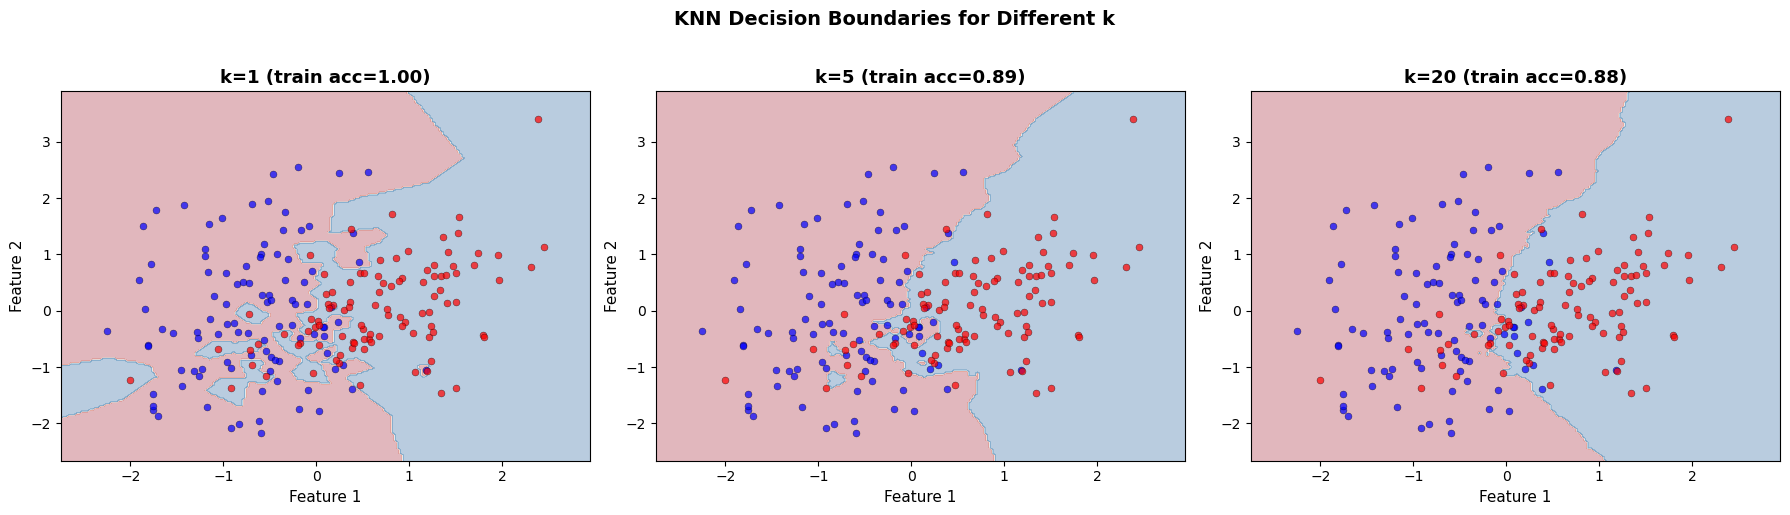

In [2]:
# 2D dataset for visualization
X_2d, y_2d = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    random_state=42, n_clusters_per_class=1
)

scaler = StandardScaler()
X_2d_s = scaler.fit_transform(X_2d)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_values = [1, 5, 20]

x_min, x_max = X_2d_s[:, 0].min() - 0.5, X_2d_s[:, 0].max() + 0.5
y_min, y_max = X_2d_s[:, 1].min() - 0.5, X_2d_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

for ax, k in zip(axes, k_values):
    knn = KNNClassifier(k=k)
    knn.fit(X_2d_s, y_2d)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_2d_s[y_2d == 0, 0], X_2d_s[y_2d == 0, 1], c='blue', s=25, alpha=0.7, edgecolors='k', lw=0.3)
    ax.scatter(X_2d_s[y_2d == 1, 0], X_2d_s[y_2d == 1, 1], c='red', s=25, alpha=0.7, edgecolors='k', lw=0.3)
    acc = accuracy_score(y_2d, knn.predict(X_2d_s))
    ax.set_title(f'k={k} (train acc={acc:.2f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)

plt.suptitle('KNN Decision Boundaries for Different k', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/knn_boundaries.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Iris Classification

In [3]:
iris = load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names

print(f"Dataset: Iris")
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Classes: {target_names} | Counts: {np.bincount(y)}")

scaler = StandardScaler()
X_s = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_s, y, test_size=0.2, random_state=42)

knn = KNNClassifier(k=5, distance='euclidean')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"\n=== KNN (k=5) on Iris ===")
print(classification_report(y_test, y_pred, target_names=list(target_names)))

Dataset: Iris
Samples: 150, Features: 4
Classes: ['setosa' 'versicolor' 'virginica'] | Counts: [50 50 50]

=== KNN (k=5) on Iris ===
     Class  Precision     Recall   F1-Score    Support
-------------------------------------------------------
    setosa     1.0000     1.0000     1.0000         10
versicolor     1.0000     1.0000     1.0000          9
 virginica     1.0000     1.0000     1.0000         11
-------------------------------------------------------
  accuracy                           1.0000         30


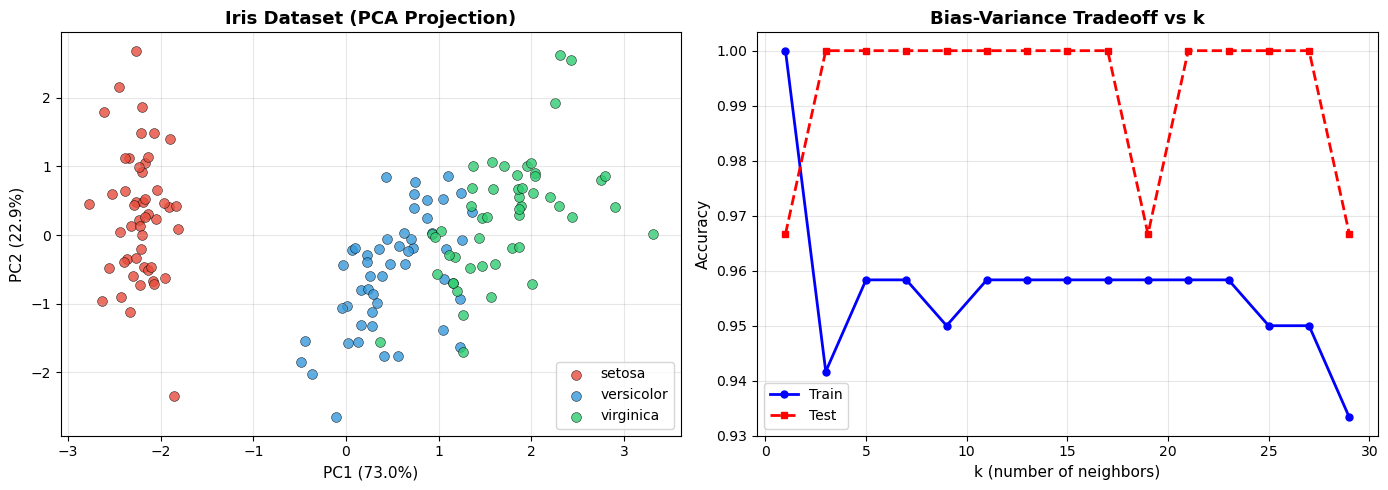

In [4]:
# Visualize with PCA projection
from sklearn.decomposition import PCA as SklearnPCA

pca = SklearnPCA(n_components=2)
X_pca = pca.fit_transform(X_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

ax = axes[0]
for i, (name, color) in enumerate(zip(target_names, colors)):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name, s=50, alpha=0.8, edgecolors='k', lw=0.4)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_title('Iris Dataset (PCA Projection)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# k vs accuracy
ax2 = axes[1]
k_range = range(1, 30, 2)
train_accs, test_accs = [], []
for k in k_range:
    m = KNNClassifier(k=k)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

ax2.plot(list(k_range), train_accs, 'bo-', linewidth=2, markersize=5, label='Train')
ax2.plot(list(k_range), test_accs, 'rs--', linewidth=2, markersize=5, label='Test')
ax2.set_xlabel('k (number of neighbors)', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Bias-Variance Tradeoff vs k', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/knn_iris.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. KNN Regression

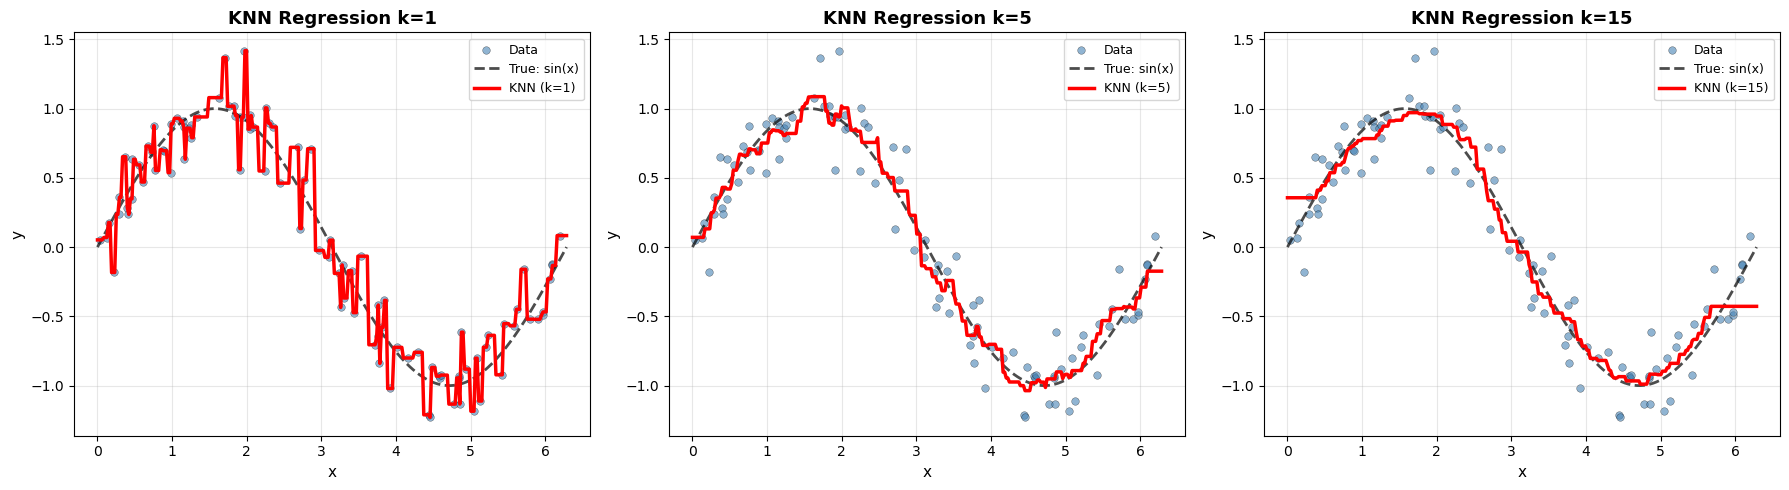

In [5]:
# 1D regression example for visualization
np.random.seed(42)
X_reg = np.sort(np.random.uniform(0, 2 * np.pi, 100)).reshape(-1, 1)
y_reg = np.sin(X_reg.ravel()) + np.random.normal(0, 0.2, 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_vals = [1, 5, 15]
X_line = np.linspace(0, 2*np.pi, 300).reshape(-1, 1)

for ax, k in zip(axes, k_vals):
    knn_reg = KNNRegressor(k=k)
    knn_reg.fit(X_reg, y_reg)
    y_line = knn_reg.predict(X_line)
    
    ax.scatter(X_reg, y_reg, c='steelblue', alpha=0.6, s=30, label='Data', edgecolors='k', lw=0.3)
    ax.plot(X_line, np.sin(X_line), 'k--', linewidth=2, label='True: sin(x)', alpha=0.7)
    ax.plot(X_line, y_line, 'r-', linewidth=2.5, label=f'KNN (k={k})')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(f'KNN Regression k={k}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/knn_regression.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Distance Metric Comparison

In [6]:
metrics_list = ['euclidean', 'manhattan', 'minkowski']
results = {}

for metric in metrics_list:
    knn_m = KNNClassifier(k=5, distance=metric)
    knn_m.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_m.predict(X_test))
    results[metric] = acc
    print(f"Distance={metric:12s}  Test Accuracy={acc:.4f}")

# sklearn comparison
sk_knn = SklearnKNN(n_neighbors=5)
sk_knn.fit(X_train, y_train)
sk_acc = accuracy_score(y_test, sk_knn.predict(X_test))
print(f"\nsklearn KNN (k=5): {sk_acc:.4f}")

Distance=euclidean     Test Accuracy=1.0000
Distance=manhattan     Test Accuracy=1.0000
Distance=minkowski     Test Accuracy=1.0000

sklearn KNN (k=5): 1.0000


## Summary

| Property | Value |
|---|---|
| Type | Non-parametric, instance-based |
| Training | None (lazy learner — stores all data) |
| Prediction | $O(n \cdot d)$ per query |
| Hyperparameter | $k$, distance metric |
| Weakness | Slow at inference, sensitive to scale and irrelevant features |

**Key Takeaways:**
- KNN is a **lazy learner** — no training phase, all work at prediction time
- Feature **normalization is essential** — features on different scales dominate distances
- Choosing $k$ requires balancing bias and variance
- Works well with small/medium datasets and low-dimensional data